In [1]:
import pandas as pd
import numpy as np

In [2]:
population_df = pd.read_csv(r"C:\Users\Dharani A\OneDrive\Desktop\AIML mini project\datasets\all.csv")

rainfall_df = pd.read_csv(r"C:\Users\Dharani A\OneDrive\Desktop\AIML mini project\datasets\rainfall_occurred_during_whole_year_tn_2018_19.csv")

forest_df = pd.read_csv(r"C:\Users\Dharani A\OneDrive\Desktop\AIML mini project\datasets\tamil_nadu_district_forest_data.csv")

crop_df = pd.read_csv(r"C:\Users\Dharani A\OneDrive\Desktop\AIML mini project\datasets\crop_production.csv")

weather_df = pd.read_csv(r"C:\Users\Dharani A\OneDrive\Desktop\AIML mini project\datasets\TNweather_1.8M.csv")

In [3]:
print(population_df.columns)

print(rainfall_df.columns)

print(forest_df.columns)

print(crop_df.columns)

print(weather_df.columns)

Index(['Unnamed: 0', 'State', 'District', 'Persons', 'Males', 'Females',
       'Growth..1991...2001.', 'Rural', 'Urban', 'Scheduled.Caste.population',
       'Percentage...SC.to.total', 'Number.of.households',
       'Household.size..per.household.', 'Sex.ratio..females.per.1000.males.',
       'Sex.ratio..0.6.years.', 'Scheduled.Tribe.population',
       'Percentage.to.total.population..ST.', 'Persons..literate',
       'Males..Literate', 'Females..Literate', 'Persons..literacy.rate',
       'Males..Literatacy.Rate', 'Females..Literacy.Rate', 'Total.Educated',
       'Data.without.level', 'Below.Primary', 'Primary', 'Middle',
       'Matric.Higher.Secondary.Diploma', 'Graduate.and.Above', 'X0...4.years',
       'X5...14.years', 'X15...59.years', 'X60.years.and.above..Incl..A.N.S..',
       'Total.workers', 'Main.workers', 'Marginal.workers', 'Non.workers',
       'SC.1.Name', 'SC.1.Population', 'SC.2.Name', 'SC.2.Population',
       'SC.3.Name', 'SC.3.Population', 'Religeon.1.Name',


In [4]:
population_df = population_df[
    population_df['State'] == 'TN'
] #returns only row state is TN

In [5]:
crop_df = crop_df[
    crop_df['State_Name'] == 'Tamil Nadu'
]#filter only state name

In [6]:
population_df = population_df[[
    'District',
    'Persons',
    'Males',
    'Females',
    'Urban',
    'Rural'
]]#select only specific column 

In [7]:
rainfall_df = rainfall_df[[
    'District',
    "Actual Rainfall occurred during June'18 to May'19 (in mm)"
]]#select only specific column

In [8]:
forest_df = forest_df[[
    'district',
    'forest_cover_percent',
    'forest_area_sqkm',
    'water_source_nearby'
]]#select only specific column

In [9]:
crop_df = crop_df[[
    'District_Name',
    'Season',
    'Crop',
    'Area',
    'Production'
]]#select only specific column

In [10]:
weather_df = weather_df[[
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'rain',
    'wind_speed_10m',
    'city'
]]#select only column name

In [11]:
population_df.rename(columns={
    'District': 'district',
    'Persons': 'population'
}, inplace=True)

In [12]:
rainfall_df.rename(columns={
    'District': 'district',
    "Actual Rainfall occurred during June'18 to May'19 (in mm)": 'rainfall_mm'
}, inplace=True)

In [13]:
crop_df.rename(columns={
    'District_Name': 'district',
    'Crop': 'crop_type',
    'Area': 'crop_area',
    'Production': 'crop_production'
}, inplace=True)

In [14]:
weather_df.rename(columns={

    'temperature_2m': 'temperature',

    'relative_humidity_2m': 'humidity',

    'wind_speed_10m': 'wind_speed',

    'city': 'district'

}, inplace=True)

In [15]:
population_df['district'] = population_df['district'].str.lower()

rainfall_df['district'] = rainfall_df['district'].str.lower()

forest_df['district'] = forest_df['district'].str.lower()

crop_df['district'] = crop_df['district'].str.lower()

weather_df['district'] = weather_df['district'].str.lower()

In [16]:
population_df.fillna(0, inplace=True)

rainfall_df.fillna(0, inplace=True)

forest_df.fillna(0, inplace=True)

crop_df.fillna(0, inplace=True)

weather_df.fillna(weather_df.mean(numeric_only=True), inplace=True)

C:\Users\Dharani A\AppData\Local\Temp\ipykernel_27540\3892454397.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  population_df.fillna(0, inplace=True)


In [17]:
population_df.drop_duplicates(inplace=True)

rainfall_df.drop_duplicates(inplace=True)

forest_df.drop_duplicates(inplace=True)

crop_df.drop_duplicates(inplace=True)

weather_df.drop_duplicates(inplace=True)

In [18]:
weather_df = weather_df.groupby('district').mean().reset_index()
#group rows district-wise
#clculate average value
#convert grouped index back into normal columns

In [19]:
merged_df = pd.merge(
    population_df,
    rainfall_df,
    on='district',
    how='inner'
)

In [20]:
merged_df = pd.merge(
    merged_df,
    forest_df,
    on='district',
    how='inner'
)

In [21]:
merged_df = pd.merge(
    merged_df,
    crop_df,
    on='district',
    how='inner'
)

In [22]:
merged_df = pd.merge(
    merged_df,
    weather_df,
    on='district',
    how='inner'
)

In [23]:
print(merged_df.head())

print(merged_df.shape)

print(merged_df.columns)

Empty DataFrame
Columns: [district, population, Males, Females, Urban, Rural, rainfall_mm, forest_cover_percent, forest_area_sqkm, water_source_nearby, Season, crop_type, crop_area, crop_production, temperature, humidity, precipitation, rain, wind_speed]
Index: []
(0, 19)
Index(['district', 'population', 'Males', 'Females', 'Urban', 'Rural',
       'rainfall_mm', 'forest_cover_percent', 'forest_area_sqkm',
       'water_source_nearby', 'Season', 'crop_type', 'crop_area',
       'crop_production', 'temperature', 'humidity', 'precipitation', 'rain',
       'wind_speed'],
      dtype='object')


In [24]:
print(merged_df.shape)

(0, 19)


In [25]:
print(weather_df['district'].unique())

['ariyalur' 'chengalpattu' 'chennai' 'coimbatore' 'cuddalore' 'dharmapuri'
 'dindigul' 'erode' 'kallakurichi' 'kanchipuram' 'kanyakumari' 'karur'
 'krishnagiri' 'madurai' 'mayiladuthurai' 'nagapattinam' 'namakkal'
 'nilgiris' 'perambalur' 'pudukkottai' 'ramanathapuram' 'ranipet' 'salem'
 'sivaganga' 'tenkasi' 'thanjavur' 'theni' 'thoothukudi' 'tiruchirappalli'
 'tirunelveli' 'tirupathur' 'tiruppur' 'tiruvallur' 'tiruvannamalai'
 'tiruvarur' 'vellore' 'viluppuram' 'virudhunagar']


In [26]:
print(rainfall_df['district'].unique())

['chennai' 'kancheepuram' 'tiruvallur' 'cuddalore' 'villupuram' 'vellore'
 'tiruvannamalai' 'salem' 'namakkal' 'dharmapuri' 'krishnagiri' 'tiruppur'
 'coimbatore' 'erode' 'tiruchirappalli' 'karur' 'perambalur' 'pudukkottai'
 'thanjavur' 'tiruvarur' 'nagapattinam' 'madurai' 'theni' 'dindigul'
 'ramanathapuram' 'virudhunagar' 'sivaganga' 'tirunelveli' 'thoothukudi'
 'the nilgiris' 'ariyalur' 'kanniyakumari' 'state average']


In [27]:
print(population_df['district'].unique())

['district thiruvallur (01), tamil nadu (33)'
 'district chennai (02), tamil nadu (33)'
 'district kancheepuram (03), tamil nadu (33)'
 'district vellore (04), tamil nadu (33)'
 'district dharmapuri (05), tamil nadu (33)'
 'district tiruvannamalai (06), tamil nadu (33)'
 'district viluppuram (07), tamil nadu (33)'
 'district salem (08), tamil nadu (33)' 'district namakkal'
 'district erode (10), tamil nadu (33)'
 'district the nilgiris (11), tamil nadu (33)'
 'district coimbatore (12), tamil nadu (33)'
 'district dindigul (13), tamil nadu (33)' 'district karur'
 'district tiruchirappalli (15), tamil nadu (33)' 'district perambalur'
 'district ariyalur' 'district cuddalore (18), tamil nadu (33)'
 'district nagapattinam' 'district thiruvarur (20), tamil nadu (33)'
 'district thanjavur (21), tamil nadu (33)'
 'district pudukkottai (22), tamil nadu (33)'
 'district sivaganga (23), tamil nadu (33)'
 'district madurai (24), tamil nadu (33)' 'district theni'
 'district virudhunagar (26), tami

In [28]:
population_df['district'] = (
    population_df['district']
    .str.lower()
    .str.replace('district ', '', regex=False)
    .str.replace(', tamil nadu (33)', '', regex=False)
    .str.replace(r'\(\d+\)', '', regex=True)
    .str.strip()
)

In [29]:
replace_dict = {

    'the nilgiris': 'nilgiris',

    'tirupur': 'tiruppur',

    'tuticorin': 'thoothukudi',

    'trichy': 'tiruchirappalli',

    'madras': 'chennai'

}

In [30]:
weather_df['district'].replace(replace_dict, inplace=True)

population_df['district'].replace(replace_dict, inplace=True)

rainfall_df['district'].replace(replace_dict, inplace=True)

forest_df['district'].replace(replace_dict, inplace=True)

crop_df['district'].replace(replace_dict, inplace=True)

C:\Users\Dharani A\AppData\Local\Temp\ipykernel_27540\2796515426.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  weather_df['district'].replace(replace_dict, inplace=True)
C:\Users\Dharani A\AppData\Local\Temp\ipykernel_27540\2796515426.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [31]:
print(sorted(population_df['district'].unique())[:30])

['ariyalur', 'chennai', 'coimbatore', 'cuddalore', 'dharmapuri', 'dindigul', 'erode', 'kancheepuram', 'kanniyakumari', 'karur', 'madurai', 'nagapattinam', 'namakkal', 'nilgiris', 'perambalur', 'pudukkottai', 'ramanathapuram', 'salem', 'sivaganga', 'thanjavur', 'theni', 'thiruvallur', 'thiruvarur', 'thoothukkudi', 'tiruchirappalli', 'tirunelveli', 'tiruvannamalai', 'vellore', 'viluppuram', 'virudhunagar']


In [32]:
common = (
    set(weather_df['district'])
    & set(population_df['district'])
    & set(rainfall_df['district'])
    & set(forest_df['district'])
    & set(crop_df['district'])
)

print(common)

print("Total Common Districts:", len(common))

{'tirunelveli', 'theni', 'vellore', 'perambalur', 'nilgiris', 'sivaganga', 'madurai', 'salem', 'karur', 'cuddalore', 'ariyalur', 'thanjavur', 'dindigul', 'tiruvannamalai', 'nagapattinam', 'ramanathapuram', 'coimbatore', 'pudukkottai', 'erode', 'namakkal', 'virudhunagar', 'dharmapuri'}
Total Common Districts: 22


In [33]:
weather_df = weather_df[
    weather_df['district'].isin(common)
]

population_df = population_df[
    population_df['district'].isin(common)
]

rainfall_df = rainfall_df[
    rainfall_df['district'].isin(common)
]

forest_df = forest_df[
    forest_df['district'].isin(common)
]

crop_df = crop_df[
    crop_df['district'].isin(common)
]

In [34]:
merged_df = pd.merge(
    population_df,
    rainfall_df,
    on='district',
    how='inner'
)

merged_df = pd.merge(
    merged_df,
    forest_df,
    on='district',
    how='inner'
)

merged_df = pd.merge(
    merged_df,
    crop_df,
    on='district',
    how='inner'
)

merged_df = pd.merge(
    merged_df,
    weather_df,
    on='district',
    how='inner'
)

In [35]:
print(merged_df.shape)

print(merged_df.head())

(10074, 19)
  district  population    Males  Females  Urban    Rural  rainfall_mm  \
0  vellore     3477317  1741083  1736234      0  2169319        537.8   
1  vellore     3477317  1741083  1736234      0  2169319        537.8   
2  vellore     3477317  1741083  1736234      0  2169319        537.8   
3  vellore     3477317  1741083  1736234      0  2169319        537.8   
4  vellore     3477317  1741083  1736234      0  2169319        537.8   

   forest_cover_percent  forest_area_sqkm  water_source_nearby       Season  \
0                 37.36            845.09                    1  Kharif        
1                 37.36            845.09                    1  Kharif        
2                 37.36            845.09                    1  Kharif        
3                 37.36            845.09                    1  Kharif        
4                 37.36            845.09                    1  Kharif        

       crop_type  crop_area  crop_production  temperature  humidity  \
0  

In [36]:
import random

def create_risk(row):

    score = 0 #initial value 0

    # Forest influence
    if row['forest_cover_percent'] > 35:
        score += 3
    elif row['forest_cover_percent'] > 20:
        score += 2
    else:
        score += 1

    # Rainfall influence
    if row['rainfall_mm'] > 800:
        score += 3
    elif row['rainfall_mm'] > 500:
        score += 2
    else:
        score += 1

    # Temperature influence
    if row['temperature'] > 28:
        score += 2

    # Crop area influence
    if row['crop_area'] > 4000:
        score += 2

    # Population pressure
    if row['population'] > 3000000:
        score += 2

    # Final classification
    if score >= 10:
        return 'High'

    elif score >= 6:
        return 'Medium'

    else:
        return 'Low'

In [37]:
merged_df['risk_level'] = merged_df.apply(
    create_risk,
    axis=1
)

In [38]:
print(
    merged_df[
        ['district', 'forest_cover_percent',
         'rainfall_mm', 'temperature',
         'risk_level']
    ].head()
)

  district  forest_cover_percent  rainfall_mm  temperature risk_level
0  vellore                 37.36        537.8    27.674746     Medium
1  vellore                 37.36        537.8    27.674746     Medium
2  vellore                 37.36        537.8    27.674746     Medium
3  vellore                 37.36        537.8    27.674746     Medium
4  vellore                 37.36        537.8    27.674746     Medium


In [39]:
merged_df.duplicated().sum()

np.int64(0)

In [40]:
print(merged_df['risk_level'].value_counts())

risk_level
Medium    5290
Low       4637
High       147
Name: count, dtype: int64


In [41]:
merged_df.to_csv(
    r"C:\Users\Dharani A\OneDrive\Desktop\AIML mini project\datasets\final_preprocessed_dataset.csv",
    index=False
)

print("Preprocessing Completed Successfully")

Preprocessing Completed Successfully


In [42]:
print(merged_df.shape)

print(merged_df.columns)

print(merged_df.head())

(10074, 20)
Index(['district', 'population', 'Males', 'Females', 'Urban', 'Rural',
       'rainfall_mm', 'forest_cover_percent', 'forest_area_sqkm',
       'water_source_nearby', 'Season', 'crop_type', 'crop_area',
       'crop_production', 'temperature', 'humidity', 'precipitation', 'rain',
       'wind_speed', 'risk_level'],
      dtype='object')
  district  population    Males  Females  Urban    Rural  rainfall_mm  \
0  vellore     3477317  1741083  1736234      0  2169319        537.8   
1  vellore     3477317  1741083  1736234      0  2169319        537.8   
2  vellore     3477317  1741083  1736234      0  2169319        537.8   
3  vellore     3477317  1741083  1736234      0  2169319        537.8   
4  vellore     3477317  1741083  1736234      0  2169319        537.8   

   forest_cover_percent  forest_area_sqkm  water_source_nearby       Season  \
0                 37.36            845.09                    1  Kharif        
1                 37.36            845.09           

In [43]:
### machine learning phase

In [44]:
X = merged_df[[
    'Males',
    'Females',
    'Urban',
    'Rural',
    'forest_area_sqkm',
    'water_source_nearby',
    'crop_production',
    'humidity',
    'precipitation',
    'wind_speed'
]]

In [45]:
y = merged_df['risk_level']

In [46]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [47]:
from sklearn.preprocessing import StandardScaler #stand
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.ensemble import RandomForestClassifier #cmbine multiple model
model = RandomForestClassifier(
    n_estimators=80, #create 80 decision tree
    max_depth=6, # max dept of each tree prevent overfitting
    min_samples_split=5,#requird rows
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [50]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(label_encoder.classes_)

Accuracy: 0.9156327543424317
              precision    recall  f1-score   support

           0       0.69      0.93      0.79        27
           1       0.94      0.89      0.92       948
           2       0.90      0.94      0.92      1040

    accuracy                           0.92      2015
   macro avg       0.85      0.92      0.88      2015
weighted avg       0.92      0.92      0.92      2015

[[ 25   0   2]
 [  0 847 101]
 [ 11  56 973]]
['High' 'Low' 'Medium']


In [51]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

               Feature  Importance
6      crop_production    0.239296
4     forest_area_sqkm    0.178449
0                Males    0.153032
1              Females    0.125293
8        precipitation    0.102371
3                Rural    0.074602
9           wind_speed    0.073497
7             humidity    0.045324
5  water_source_nearby    0.008136
2                Urban    0.000000


In [52]:
###confusion matrix

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 25   0   2]
 [  0 847 101]
 [ 11  56 973]]


In [54]:
import joblib

joblib.dump(model, "../models/wildlife_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [55]:
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']

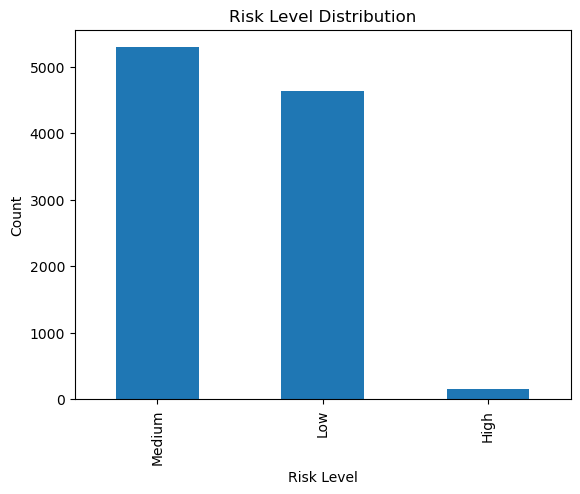

In [56]:
import matplotlib.pyplot as plt
merged_df['risk_level'].value_counts().plot(
    kind='bar'
)

plt.title("Risk Level Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Count")

plt.show()

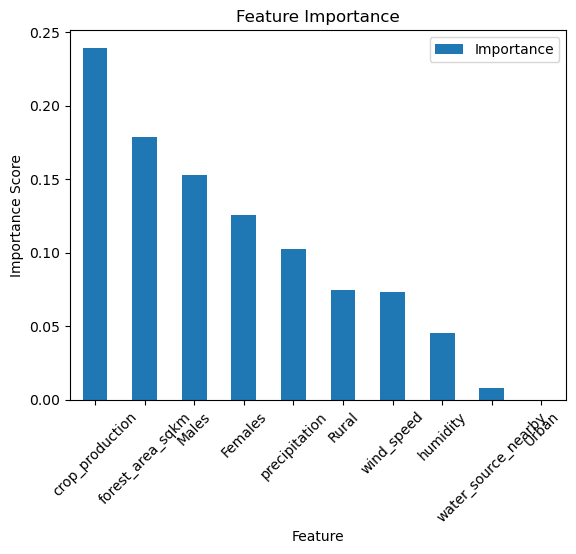

In [57]:
importance_df.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

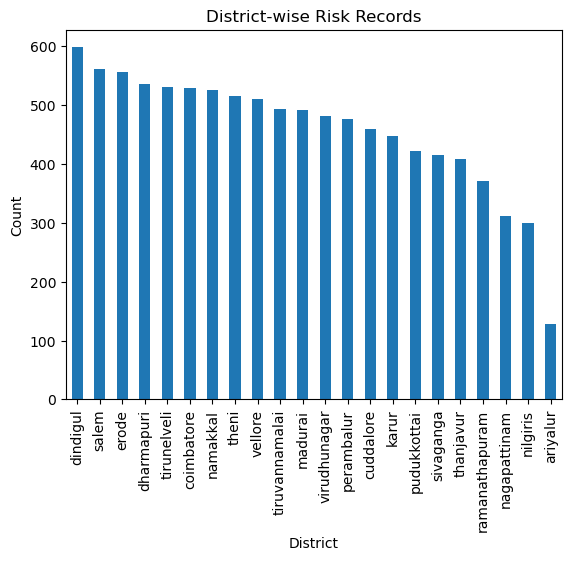

In [58]:
#district wise risk count
district_risk = merged_df.groupby(
    'district'
)['risk_level'].count()

district_risk = district_risk.sort_values(
    ascending=False
)

district_risk.plot(kind='bar')

plt.title("District-wise Risk Records")

plt.xlabel("District")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()


In [59]:
# Animal Type Prediction

In [60]:
def assign_animal(row):

    crop = str(row['crop_type']).lower()

    district = str(row['district']).lower()

    forest = row['forest_cover_percent']

    rainfall = row['rainfall_mm']


    # ELEPHANT CONDITIONS
    if (
        forest > 30 and
        crop in ['banana', 'sugarcane', 'rice']
    ):
        return 'Elephant'


    # WILD BOAR CONDITIONS
    elif (
        crop in ['maize', 'groundnut', 'millets']
    ):
        return 'Wild Boar'


    # MONKEY CONDITIONS
    elif (
        crop in ['fruits', 'banana']
    ):
        return 'Monkey'


    # LEOPARD CONDITIONS
    elif (
        district in ['nilgiris', 'coimbatore', 'erode']
        and forest > 25
    ):
        return 'Leopard'


    else:
        return 'Deer'

In [61]:
merged_df['animal_type'] = merged_df.apply(
    assign_animal,
    axis=1
)

In [62]:
print(
    merged_df[
        ['district', 'crop_type', 'animal_type']
    ].head(20)
)
print(
    merged_df['animal_type'].value_counts()
)

   district          crop_type animal_type
0   vellore             Banana    Elephant
1   vellore         Horse-gram        Deer
2   vellore              Onion        Deer
3   vellore            Sesamum        Deer
4   vellore      Small millets        Deer
5   vellore          Arhar/Tur        Deer
6   vellore              Bajra        Deer
7   vellore             Banana    Elephant
8   vellore          Cashewnut        Deer
9   vellore        Castor seed        Deer
10  vellore          Coriander        Deer
11  vellore       Cotton(lint)        Deer
12  vellore       Dry chillies        Deer
13  vellore               Gram        Deer
14  vellore          Groundnut   Wild Boar
15  vellore              Jowar        Deer
16  vellore              Maize   Wild Boar
17  vellore  Moong(Green Gram)        Deer
18  vellore              Onion        Deer
19  vellore       Pulses total        Deer
animal_type
Deer         7611
Leopard      1159
Wild Boar     751
Elephant      339
Monkey       

In [63]:
#train the model


In [64]:
X_animal = merged_df[[
    'forest_area_sqkm',
    'rainfall_mm',
    'humidity',
    'precipitation',
    'crop_production',
    'wind_speed'
]]
y_animal = merged_df['animal_type']

In [65]:
from sklearn.preprocessing import LabelEncoder

animal_encoder = LabelEncoder()

y_animal = animal_encoder.fit_transform(
    y_animal
)

In [66]:
from sklearn.preprocessing import StandardScaler

scaler_animal = StandardScaler()

X_animal_scaled = scaler_animal.fit_transform(
    X_animal
)

In [67]:
from sklearn.model_selection import train_test_split

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_animal_scaled,
    y_animal,
    test_size=0.2,
    random_state=42
)

In [68]:
#train model
from sklearn.ensemble import RandomForestClassifier

animal_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

animal_model.fit(
    X_train_a,
    y_train_a
)

RandomForestClassifier(random_state=42)

In [69]:
y_pred_a = animal_model.predict(
    X_test_a
)

In [70]:
from sklearn.metrics import accuracy_score

accuracy_a = accuracy_score(
    y_test_a,
    y_pred_a
)

print("Animal Prediction Accuracy:", accuracy_a)

Animal Prediction Accuracy: 0.8640198511166253


In [71]:
print(animal_encoder.classes_)

['Deer' 'Elephant' 'Leopard' 'Monkey' 'Wild Boar']


In [78]:
import joblib

joblib.dump(
    animal_model,
    "../models/animal_model.pkl"
)

['../models/animal_model.pkl']

In [81]:
joblib.dump(
    animal_encoder,
    "../models/animal_encoder.pkl"
)

['../models/animal_encoder.pkl']

In [88]:
joblib.dump(
    scaler_animal,
    "../models/animal_scaler.pkl"
)

animal_scaler = joblib.load(
    "../models/animal_scaler.pkl"
)

In [85]:
print(X_animal.columns)

Index(['forest_area_sqkm', 'rainfall_mm', 'humidity', 'precipitation',
       'crop_production', 'wind_speed'],
      dtype='object')


In [89]:
sample = np.array([[
    600,
    29,
    35,
    400000,
    5000,
    70
]])

sample_scaled = animal_scaler.transform(
    sample
)

pred = animal_model.predict(
    sample_scaled
)

print(
    animal_encoder.inverse_transform(pred)
)

['Deer']


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [79]:
import joblib

model = joblib.load(r"C:\Users\Dharani A\OneDrive\Desktop\AIML mini project\models\wildlife_model.pkl")

print(model)

RandomForestClassifier(max_depth=6, min_samples_split=5, n_estimators=80,
                       random_state=42)


In [80]:
import joblib

label_encoder = joblib.load(
    r"C:\Users\Dharani A\OneDrive\Desktop\AIML mini project\models\label_encoder.pkl"
)

print(label_encoder.classes_)

['High' 'Low' 'Medium']
